## Step 1: Data Generation and Loading
We will simulate the daily sales flow of a coffee shop, including events and weather for our EDA analysis.

In [3]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
random.seed(42)

n = 365
weathers = ["Sunny", "Rainy", "Cloudy"]
data = []

for _ in range(n):
    temperature = round(random.uniform(15.0, 35.0), 1)
    ad_investment = round(random.uniform(10.0, 150.0), 2)
    nearby_events = random.choice([0, 1])
    applied_discount = random.choice([0, 10, 15, 20])
    weather = random.choice(weathers)
    
    sales = (
        500 + 
        (ad_investment * 2.5) - 
        (temperature * 8) + 
        (nearby_events * 250) + 
        (applied_discount * 5)
    )
    
    if weather == "Rainy": sales += 150
    elif weather == "Sunny": sales -= 50
    
    sales += np.random.normal(0, 80)
    
    data.append([temperature, ad_investment, nearby_events, applied_discount, weather, round(sales, 2)])

columns = ["temperature_c", "ad_investment", "local_event", "discount", "weather", "daily_sales"]
df = pd.DataFrame(data, columns=columns)
df.head()

,temperature_c,ad_investment,local_event,discount,weather,daily_sales
0,27.8,13.50,1,10,Sunny,601.09
1,17.8,24.35,0,20,Sunny,457.41
2,15.6,40.61,0,10,Cloudy,578.54
3,28.0,86.29,0,20,Cloudy,713.57
4,20.6,131.70,0,20,Rainy,895.72


## Step 2: Initial Exploratory Analysis
Let's analyze how the dataset behaves using built-in tools to see general descriptives, maximums, and actual averages.

In [7]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature_c  365 non-null    float64
 1   ad_investment  365 non-null    float64
 2   local_event    365 non-null    int64  
 3   discount       365 non-null    int64  
 4   weather        365 non-null    object 
 5   daily_sales    365 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 17.2+ KB
None
       temperature_c  ad_investment  local_event    discount  daily_sales
count     365.000000     365.000000   365.000000  365.000000   365.000000
mean       24.648767      82.490247     0.561644   11.684932   735.927151
std         5.687482      40.828333     0.496867    7.270059   204.863687
min        15.100000      10.060000     0.000000    0.000000   226.620000
25%        19.800000      48.400000     0.000000   10.000000   576.890000
50%        24.500000      84.780

## Step 3: Strategic Visualization
Here we create the histogram, scatter plot, and matrix to find the correlation between temperature, advertising, and event variables against daily sales.

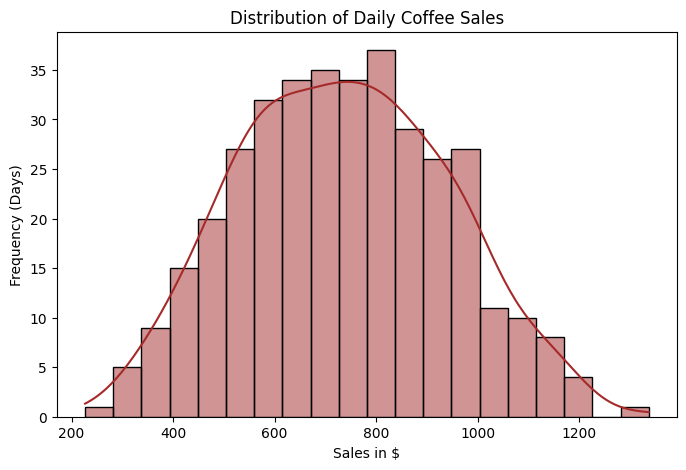

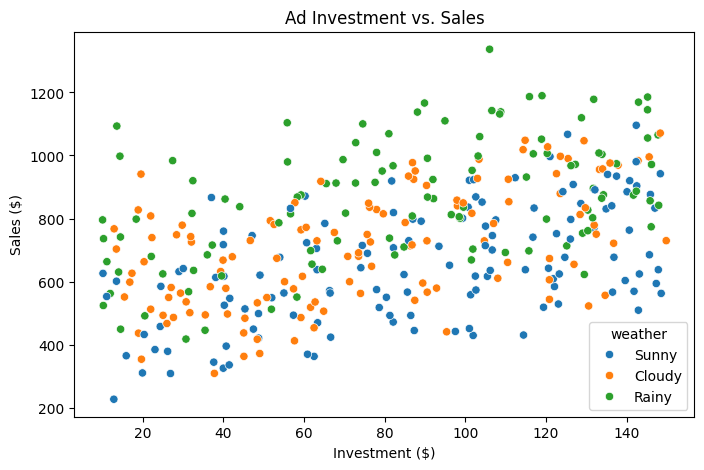

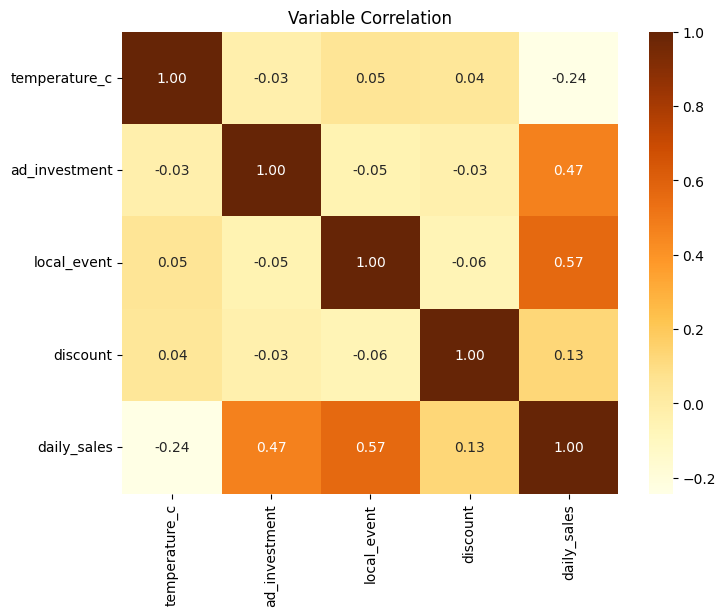

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["daily_sales"], bins=20, kde=True, color="brown")
plt.title("Distribution of Daily Coffee Sales")
plt.xlabel("Sales in $")
plt.ylabel("Frequency (Days)")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="ad_investment", y="daily_sales", hue="weather", data=df)
plt.title("Ad Investment vs. Sales")
plt.xlabel("Investment ($)")
plt.ylabel("Sales ($)")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlOrBr", fmt=".2f")
plt.title("Variable Correlation")
plt.show()

## Steps 4 and 5: Modeling and Performance Evaluation
Predict sales and validate the model error.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_encoded = pd.get_dummies(df, columns=["weather"])
X = df_encoded.drop("daily_sales", axis=1)
y = df_encoded["daily_sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

coffee_shop_model = LinearRegression()
coffee_shop_model.fit(X_train, y_train)
predictions = coffee_shop_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: $55.39
RMSE: $74.51
R²: 0.88
